# cGAN Baseline — 128×128  (No MediaPipe)
### Model A: All v4 architectural improvements, zero MediaPipe supervision
**Changes from original v4:**
- `IMG_SIZE = 128` → higher resolution, better quality ceiling
- Generator adds one extra upsample stage: 4→8→16→32→64→**128**
- Discriminator input is 128×128, label projection is 128×128
- SelfAttention placed at **32×32** (same relative position as before)
- No landmark cache, no structural loss, no MediaPipe imports
- Everything else identical: SpectralNorm, asymmetric LR, adaptive G:D, label smoothing


## Section 1 — Environment

In [ ]:
# ── Environment detection (Colab vs local Linux/WSL) ────────────────────────────
import os, sys

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def _find_repo_root(start):
    d = os.path.abspath(start)
    for _ in range(5):
        if os.path.isdir(os.path.join(d, 'data')) and os.path.isdir(os.path.join(d, 'notebooks')):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    return os.path.abspath(start)

REPO_ROOT = None if IN_COLAB else _find_repo_root(os.getcwd())
print('Environment:', 'Google Colab' if IN_COLAB else f'Local ({sys.platform}) - repo root: {REPO_ROOT}')


In [ ]:
# ── Install (pinned for reproducibility) ──────────────────────────────────────
if IN_COLAB:
    !pip install tensorflow==2.19.0 opencv-python --quiet
    !pip install pytorch-fid scikit-image scikit-learn tqdm lpips --quiet
    !pip install torch torchvision --quiet
    print("All packages installed.")
else:
    print('Running locally -- make sure this environment has: tensorflow==2.19.0 (tensorflow[and-cuda] for GPU on Linux/WSL), opencv-python, pytorch-fid, scikit-image, scikit-learn, tqdm, lpips, torch, torchvision.')


In [ ]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print('Not running in Colab -- skipping Drive mount; using local paths.')


In [ ]:
# ── Imports ────────────────────────────────────────────────────────────────────
import os, json, csv, warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from collections import Counter
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
from skimage.metrics import structural_similarity as ssim_fn

import cv2

warnings.filterwarnings('ignore', category=UserWarning)
print(f"TensorFlow : {tf.__version__}")
print(f"OpenCV     : {cv2.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")


TensorFlow : 2.19.0
OpenCV     : 4.13.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── Global reproducibility ─────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f"Global seed: {RANDOM_SEED}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"GPU memory growth enabled: {gpus[0].name}")
    except RuntimeError as e:
        print(f"GPU config warning: {e}")


Global seed: 42
GPU memory growth enabled: /physical_device:GPU:0


In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────────
DRIVE_BASE     = "/content/drive/MyDrive/cgan_A_128" if IN_COLAB else os.path.join(REPO_ROOT, "runs", "cgan_A_128")
DATA_PATH      = "/content/ArASL_Database_54K_Final" if IN_COLAB else os.path.join(REPO_ROOT, "data", "ArASL_dataset")

CHECKPOINT_DIR = os.path.join(DRIVE_BASE, "checkpoints")
SAMPLES_DIR    = os.path.join(DRIVE_BASE, "samples")
EVAL_DIR       = os.path.join(DRIVE_BASE, "eval")
REAL_FID_DIR   = os.path.join(EVAL_DIR,   "fid_real")
HISTORY_DIR    = os.path.join(DRIVE_BASE, "history")
PLOTS_DIR      = os.path.join(DRIVE_BASE, "plots")
PROGRESS_FILE  = os.path.join(CHECKPOINT_DIR, "progress.json")

for d in [CHECKPOINT_DIR, SAMPLES_DIR, EVAL_DIR, REAL_FID_DIR, HISTORY_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("All directories ready.")
for d in [CHECKPOINT_DIR, SAMPLES_DIR, EVAL_DIR, HISTORY_DIR, PLOTS_DIR]:
    print(f"  {d}")


In [ ]:
# ── Dataset — auto-download from Hugging Face (no manual Drive upload needed) ──
# Source: pain/ArASL_Database_Grayscale on Hugging Face (54,049 imgs, 32 classes).
# Downloads straight to local Colab disk once per session — faster than reading
# from Drive and doesn't touch your Drive quota. Re-running is a no-op if present.
import pandas as pd

if not os.path.isdir(DATA_PATH) or not os.listdir(DATA_PATH):
    import io as _io, json as _json, urllib.request as _req
    try:
        import pyarrow.parquet as pq
    except ImportError:
        import subprocess; subprocess.run(["pip", "install", "-q", "pyarrow"]); import pyarrow.parquet as pq

    _parquet = "/content/arasl.parquet"
    if not os.path.exists(_parquet):
        print("Downloading ArASL dataset from Hugging Face (~30 MB)...")
        _req.urlretrieve(
            "https://huggingface.co/api/datasets/pain/ArASL_Database_Grayscale/parquet/default/train/0.parquet",
            _parquet)

    _names = ["ain","al","aleff","bb","dal","dha","dhad","fa","gaaf","ghain","ha","haa",
              "jeem","kaaf","khaa","la","laam","meem","nun","ra","saad","seen","sheen",
              "ta","taa","thaa","thal","toot","waw","ya","yaa","zay"]
    try:
        _md = pq.read_schema(_parquet).metadata or {}
        _hf = _md.get(b"huggingface")
        if _hf:
            _names = _json.loads(_hf)["info"]["features"]["label"]["names"]
    except Exception as e:
        print("metadata note:", e)

    os.makedirs(DATA_PATH, exist_ok=True)
    for n in _names:
        os.makedirs(os.path.join(DATA_PATH, n), exist_ok=True)

    _df = pd.read_parquet(_parquet)
    _counts = {}
    for v, lab in zip(_df["image"], _df["label"]):
        b = v["bytes"] if isinstance(v, dict) else v
        cls = _names[int(lab)] if int(lab) < len(_names) else f"class_{int(lab):02d}"
        k = _counts.get(cls, 0); _counts[cls] = k + 1
        Image.open(_io.BytesIO(b)).convert("L").save(os.path.join(DATA_PATH, cls, f"{cls}_{k:04d}.png"))
    print(f"Dataset ready: {sum(_counts.values())} images across {len(_counts)} classes -> {DATA_PATH}")
else:
    print(f"Dataset already present at {DATA_PATH} — skipping download.")


## Section 2 — Hyperparameters

In [ ]:
# ════════════════════════════════════════════════════════
#  CONFIGURATION — change only this cell
# ════════════════════════════════════════════════════════

# Architecture
Z_DIM        = 128    # latent noise dimension
IMG_SIZE     = 128    # ← upgraded from 64 to 128
IMG_CHANNELS = 1      # grayscale

# Training
EPOCHS         = 50
BATCH_SIZE     = 32   # halved vs 64px (memory: 128px images are 4× larger)
LR_G           = 2e-4
LR_D           = 1e-4  # asymmetric: D converges faster
LR_DECAY_G     = 35
LR_DECAY_D     = 20
LABEL_SMOOTH   = 0.9   # real-label smoothing

# GAN balance
G_UPDATES_BASE = 2
G_D_RATIO_MAX  = 2.0

# Evaluation
N_FID_PER_CLASS  = 60
N_FID_SEEDS      = 5
N_PKLE_PER_CLASS = 15
SAVE_EVERY_N     = 5

print("Model A — cGAN 128×128 (No MediaPipe)")
print(f"  IMG_SIZE   = {IMG_SIZE}")
print(f"  BATCH_SIZE = {BATCH_SIZE}  (halved for 128px memory)")
print(f"  LR_G={LR_G}, LR_D={LR_D}  (asymmetric)")
print(f"  D decay ep{LR_DECAY_D}, G decay ep{LR_DECAY_G}")
print(f"  No structural / landmark loss")


Model A — cGAN 128×128 (No MediaPipe)
  IMG_SIZE   = 128
  BATCH_SIZE = 32  (halved for 128px memory)
  LR_G=0.0002, LR_D=0.0001  (asymmetric)
  D decay ep20, G decay ep35
  No structural / landmark loss


## Section 3 — Data Loading

In [ ]:
# ── Load images at 128×128 ─────────────────────────────────────────────────────
VALID_EXT = ('.png', '.jpg', '.jpeg')
images_list_pre, labels_list_pre = [], []
load_errors = 0

print(f"Loading from: {DATA_PATH}  (resizing to {IMG_SIZE}×{IMG_SIZE})")
for subfolder in tqdm(sorted(os.listdir(DATA_PATH)), desc="Classes"):
    spath = os.path.join(DATA_PATH, subfolder)
    if not os.path.isdir(spath):
        continue
    for fname in sorted(os.listdir(spath)):
        if not fname.lower().endswith(VALID_EXT):
            continue
        try:
            raw = tf.io.read_file(os.path.join(spath, fname))
            img = tf.image.decode_png(raw, channels=1)
            img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])   # bilinear → 128×128
            img = tf.cast(img, tf.float32)
            img = (img - 127.5) / 127.5                        # [-1, 1]
            images_list_pre.append(img.numpy())
            labels_list_pre.append(subfolder)
        except Exception:
            load_errors += 1

print(f"Loaded : {len(images_list_pre)} images")
print(f"Errors : {load_errors}")


Loading from: /content/drive/MyDrive/ArASL_Database_54K_Final/ArASL_Database_54K_Final  (resizing to 128×128)


Classes: 100%|██████████| 32/32 [29:59<00:00, 56.24s/it]

Loaded : 54049 images
Errors : 0


In [ ]:
# ── NumPy arrays + label encoding ─────────────────────────────────────────────
images_array_pre = np.array(images_list_pre, dtype=np.float32)
labels_array_pre = np.array(labels_list_pre)

label_encoder  = LabelEncoder()
labels_int_pre = label_encoder.fit_transform(labels_array_pre)
num_classes    = len(label_encoder.classes_)
label_to_idx   = {l: i for i, l in enumerate(label_encoder.classes_)}
idx_to_label   = {i: l for l, i in label_to_idx.items()}

np.save(os.path.join(CHECKPOINT_DIR, "classes.npy"), label_encoder.classes_)

print(f"Images shape : {images_array_pre.shape}")
print(f"Pixel range  : [{images_array_pre.min():.3f}, {images_array_pre.max():.3f}]")
print(f"Classes      : {num_classes}")
print(f"Class list   : {list(label_encoder.classes_)}")


Images shape : (54049, 128, 128, 1)
Pixel range  : [-1.000, 1.000]
Classes      : 32
Class list   : [np.str_('ain'), np.str_('al'), np.str_('aleff'), np.str_('bb'), np.str_('dal'), np.str_('dha'), np.str_('dhad'), np.str_('fa'), np.str_('gaaf'), np.str_('ghain'), np.str_('ha'), np.str_('haa'), np.str_('jeem'), np.str_('kaaf'), np.str_('khaa'), np.str_('la'), np.str_('laam'), np.str_('meem'), np.str_('nun'), np.str_('ra'), np.str_('saad'), np.str_('seen'), np.str_('sheen'), np.str_('ta'), np.str_('taa'), np.str_('thaa'), np.str_('thal'), np.str_('toot'), np.str_('waw'), np.str_('ya'), np.str_('yaa'), np.str_('zay')]


In [ ]:
# ── Class balance ──────────────────────────────────────────────────────────────
total  = len(images_array_pre)
counts = Counter(labels_array_pre)
print(f"Dataset: {total} images  ·  {num_classes} classes")
print(f"Range: [{min(counts.values())}, {max(counts.values())}] images/class")
for cls in sorted(counts):
    n   = counts[cls]
    bar = '█' * int(n / total * 200)
    print(f"  {cls:10s}: {n:5d} ({n/total*100:.1f}%) {bar}")


Dataset: 54049 images  ·  32 classes
Range: [1293, 2114] images/class
  ain       :  2114 (3.9%) ███████
  al        :  1343 (2.5%) ████
  aleff     :  1672 (3.1%) ██████
  bb        :  1791 (3.3%) ██████
  dal       :  1634 (3.0%) ██████
  dha       :  1723 (3.2%) ██████
  dhad      :  1670 (3.1%) ██████
  fa        :  1955 (3.6%) ███████
  gaaf      :  1705 (3.2%) ██████
  ghain     :  1977 (3.7%) ███████
  ha        :  1592 (2.9%) █████
  haa       :  1526 (2.8%) █████
  jeem      :  1552 (2.9%) █████
  kaaf      :  1774 (3.3%) ██████
  khaa      :  1607 (3.0%) █████
  la        :  1746 (3.2%) ██████
  laam      :  1832 (3.4%) ██████
  meem      :  1765 (3.3%) ██████
  nun       :  1819 (3.4%) ██████
  ra        :  1659 (3.1%) ██████
  saad      :  1895 (3.5%) ███████
  seen      :  1638 (3.0%) ██████
  sheen     :  1507 (2.8%) █████
  ta        :  1816 (3.4%) ██████
  taa       :  1838 (3.4%) ██████
  thaa      :  1766 (3.3%) ██████
  thal      :  1582 (2.9%) █████
  toot      :  1

In [ ]:
# ── Shuffle ────────────────────────────────────────────────────────────────────
rng         = np.random.default_rng(RANDOM_SEED)
shuffle_idx = np.arange(len(images_array_pre))
rng.shuffle(shuffle_idx)

images_array = images_array_pre[shuffle_idx]
labels_int   = labels_int_pre[shuffle_idx]

assert images_array.shape[0] == labels_int.shape[0], "Alignment mismatch!"

print(f"Shuffle applied (seed={RANDOM_SEED})")
print(f"  images_array : {images_array.shape}")
print(f"  labels_int   : {labels_int.shape}")
print(f"  First 5 classes: {[idx_to_label[i] for i in labels_int[:5]]}")


Shuffle applied (seed=42)
  images_array : (54049, 128, 128, 1)
  labels_int   : (54049,)
  First 5 classes: [np.str_('thaa'), np.str_('ghain'), np.str_('jeem'), np.str_('ha'), np.str_('ain')]


In [ ]:
# ── Per-class image prototypes (for Phase-1 structural target) ─────────────────
class_image_prototypes = np.zeros((num_classes, IMG_SIZE, IMG_SIZE, 1), dtype=np.float32)
class_real_indices     = {}

for cls_idx in range(num_classes):
    idx_arr = np.where(labels_int == cls_idx)[0]
    class_real_indices[cls_idx] = idx_arr
    if len(idx_arr) > 0:
        class_image_prototypes[cls_idx] = images_array[idx_arr].mean(axis=0)

class_img_proto_tf = tf.constant(class_image_prototypes)
print(f"Image prototypes built: {class_image_prototypes.shape}")


Image prototypes built: (32, 128, 128, 1)


## Section 4 — Model Architecture (128×128, No MediaPipe)

### Generator — 6 upsample stages (4→8→16→32→64→128)
- Extra `Conv2DTranspose` stage vs 64px version
- `SelfAttention2D` placed at **32×32** (same relative depth)
- `γ` initialised at 0 — attention activates gradually

### Discriminator — 5 downsample stages (128→64→32→16→8→flat)
- Extra `Conv2D` stride-2 layer vs 64px version
- `SpectralNormalization` on all Conv layers
- Label spatial projection: 128×128×1 map


In [ ]:
# ── Self-attention (SAGAN-style, gamma=0 init) ─────────────────────────────────
class SelfAttention2D(tf.keras.layers.Layer):
    """
    SAGAN-style self-attention for spatial feature maps.
    gamma initialised at 0 → attention bypassed at start, activates gradually.
    Reference: Zhang et al. (2019).
    """
    def __init__(self, channels, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        ch8 = max(channels // 8, 1)
        self.q     = tf.keras.layers.Conv2D(ch8, 1, use_bias=False)
        self.k     = tf.keras.layers.Conv2D(ch8, 1, use_bias=False)
        self.v     = tf.keras.layers.Conv2D(channels, 1, use_bias=False)
        self.gamma = None

    def build(self, input_shape):
        self.gamma = self.add_weight(
            name='gamma', shape=(), initializer='zeros', trainable=True)
        super().build(input_shape)

    def call(self, x):
        B       = tf.shape(x)[0]
        H, W, C = x.shape[1], x.shape[2], x.shape[3]
        ch8     = max(C // 8, 1)
        q    = tf.reshape(self.q(x), [B, H * W, ch8])
        k    = tf.reshape(self.k(x), [B, H * W, ch8])
        v    = tf.reshape(self.v(x), [B, H * W, C])
        s    = tf.cast(ch8, tf.float32) ** -0.5
        attn = tf.nn.softmax(tf.matmul(q, k, transpose_b=True) * s, axis=-1)
        out  = tf.reshape(tf.matmul(attn, v), [B, H, W, C])
        return x + self.gamma * out

    def get_config(self):
        cfg = super().get_config()
        cfg['channels'] = self.channels
        return cfg


In [ ]:
# ── Generator A — 128×128, No MediaPipe ──────────────────────────────────────
def build_generator(z_dim, num_classes):
    """
    z_dim(128) + label_emb(128) → 256-d → Dense(4×4×512)
    → 5× Conv2DTranspose → SelfAttention at 32×32 → 128×128×1 tanh
    Upsample path: 4→8→16→32→64→128
    """
    noise_in = tf.keras.Input(shape=(z_dim,),       name="noise")
    label_in = tf.keras.Input(shape=(num_classes,), name="label")

    # Label embedding — 128-d (stronger than raw one-hot)
    lbl = tf.keras.layers.Dense(128, use_bias=False, name="lbl_emb")(label_in)
    lbl = tf.keras.layers.LeakyReLU(negative_slope=0.2)(lbl)

    x = tf.keras.layers.Concatenate()([noise_in, lbl])   # 256-d
    x = tf.keras.layers.Dense(4 * 4 * 512, use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Reshape((4, 4, 512))(x)

    # 4→8
    x = tf.keras.layers.Conv2DTranspose(256, 4, 2, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x); x = tf.keras.layers.ReLU()(x)

    # 8→16
    x = tf.keras.layers.Conv2DTranspose(128, 4, 2, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x); x = tf.keras.layers.ReLU()(x)

    # 16→32
    x = tf.keras.layers.Conv2DTranspose(128, 4, 2, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x); x = tf.keras.layers.ReLU()(x)
    x = SelfAttention2D(128, name="self_attn")(x)   # ← 32×32 global structure

    # 32→64
    x = tf.keras.layers.Conv2DTranspose(64, 4, 2, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x); x = tf.keras.layers.ReLU()(x)

    # 64→128  ← extra stage for 128px
    x = tf.keras.layers.Conv2DTranspose(32, 4, 2, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x); x = tf.keras.layers.ReLU()(x)

    out = tf.keras.layers.Conv2D(1, 3, padding='same', activation='tanh', name="img_out")(x)
    return tf.keras.Model([noise_in, label_in], out, name="Generator_A_128")


In [ ]:
# ── Discriminator A — 128×128, SpectralNorm ───────────────────────────────────
def build_discriminator(num_classes):
    """
    SpectralNormalization on all Conv layers.
    Early label injection: 128×128 spatial projection.
    Downsample: 128→64→32→16→8→4 → Flatten → Dense(1)
    """
    SN = tf.keras.layers.SpectralNormalization

    image_in = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name="image")
    label_in = tf.keras.Input(shape=(num_classes,),           name="label")

    # Spatial label projection — 128×128×1 map
    lp = layers.Dense(IMG_SIZE * IMG_SIZE)(label_in)
    lp = layers.Reshape((IMG_SIZE, IMG_SIZE, 1))(lp)
    x  = layers.Concatenate()([image_in, lp])   # (128,128,2)

    # 128→64
    x = SN(layers.Conv2D(64,  (4,4), strides=2, padding='same'))(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    # 64→32
    x = SN(layers.Conv2D(128, (4,4), strides=2, padding='same'))(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.2)(x)

    # 32→16
    x = SN(layers.Conv2D(256, (4,4), strides=2, padding='same'))(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.2)(x)

    # 16→8
    x = SN(layers.Conv2D(512, (4,4), strides=2, padding='same'))(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.3)(x)

    # 8→4  ← extra stage for 128px
    x = SN(layers.Conv2D(512, (4,4), strides=2, padding='same'))(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x   = layers.Flatten()(x)
    out = layers.Dense(1)(x)
    return tf.keras.Model([image_in, label_in], out, name="Discriminator_A_128")


In [ ]:
# ── Build + inspect ────────────────────────────────────────────────────────────
generator     = build_generator(Z_DIM, num_classes)
discriminator = build_discriminator(num_classes)

generator.summary()
print()
discriminator.summary()
print(f"\nGenerator     : {generator.count_params():,} params")
print(f"Discriminator : {discriminator.count_params():,} params")
print(f"D/G ratio     : {discriminator.count_params()/generator.count_params():.2f}x")


Model: "Generator_A_128"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None, 32)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lbl_emb (Dense)     │ (None, 128)       │      4,096 │ label[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise (InputLayer)  │ (None, 128)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128)       │          0 │ lbl_emb[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ noise[0][0],      │
│ (Concatenate)       │                   │            │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8192)      │  2,097,152 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8192)      │     32,768 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 8192)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 4, 4, 512) │          0 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 8, 256) │  2,097,152 │ reshape[0][0]     │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 16, 16,    │    524,288 │ re_lu_1[0][0]     │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 32, 32,    │    262,144 │ re_lu_2[0][0]     │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attn           │ (None, 32, 32,    │     20,481 │ re_lu_3[0][0]     │
│ (SelfAttention2D)   │ 128)              │            │                 

 Total params: 5,204,642 (19.85 MB)

 Trainable params: 5,187,042 (19.79 MB)

 Non-trainable params: 17,600 (68.75 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None, 32)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16384)     │    540,672 │ label[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 128, 128,  │          0 │ dense_1[0][0]     │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ image[0][0],      │
│ (Concatenate)       │ 2)                │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 64, 64,    │      2,176 │ concatenate_1[0]… │
│ (SpectralNormaliza… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 64, 64,    │          0 │ spectral_normali… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 32, 32,    │    131,328 │ leaky_re_lu_1[0]… │
│ (SpectralNormaliza… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 32, 32,    │          0 │ spectral_normali… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 32,    │          0 │ leaky_re_lu_2[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 16, 16,    │    524,800 │ dropout[0][0]     │
│ (SpectralNormaliza… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 16, 16,    │          0 │ spectral_normali… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16, 16,    │          0 │ leaky_re_lu_3[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 8, 8, 512) │  2,098,176 │ dropout_1[0][0]   │
│ (SpectralNormaliza… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 8, 8, 512) │          0 │ spectral_normali… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 8, 8, 512) │          0 │ leaky_re_lu_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 4, 4, 512) │  4,195,328 │ dropout_2[0][0]   │
│ (SpectralNormaliza… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 4, 4, 512) │          0 │ spectral_normali

 Total params: 7,500,673 (28.61 MB)

 Trainable params: 7,499,201 (28.61 MB)

 Non-trainable params: 1,472 (5.75 KB)


Generator     : 5,204,642 params
Discriminator : 7,500,673 params
D/G ratio     : 1.44x


## Section 5 — Loss Functions (No MediaPipe)

**G total = G_adversarial + λ × G_pixel**

Since there is no MediaPipe, the structural loss is a pure **pixel-level L1** against
real class members (Phase 2) — same warm-up and two-phase design as v4, just without landmark geometry.

| Phase | Target | Loss |
|---|---|---|
| Phase 1 (ep ≤ 10) | Class mean image | MSE |
| Phase 2 (ep > 10) | Random real class member | L1 |


In [ ]:
# ── Lambda warm-up schedule (identical to v4) ──────────────────────────────────
LAMBDA_START = 0.5
LAMBDA_END   = 5.0
WARMUP_EP    = 10
PHASE2_EP    = 10

def get_lambda(epoch):
    if epoch >= WARMUP_EP:
        return float(LAMBDA_END)
    t = epoch / max(WARMUP_EP, 1)
    return float(LAMBDA_START + t * (LAMBDA_END - LAMBDA_START))

print("λ warm-up schedule:")
for ep in [0, 5, 10, 20, 35, 50]:
    print(f"  Epoch {ep:3d}: λ={get_lambda(ep):.2f}")


λ warm-up schedule:
  Epoch   0: λ=0.50
  Epoch   5: λ=2.75
  Epoch  10: λ=5.00
  Epoch  20: λ=5.00
  Epoch  35: λ=5.00
  Epoch  50: λ=5.00


## Section 6 — Visualisation Utilities

In [ ]:
# ── Fixed evaluation noise ─────────────────────────────────────────────────────
TEST_LABELS = [l for l in ["bb","ain","gaaf","al","ha"] if l in label_to_idx]
tf.random.set_seed(RANDOM_SEED)
EVAL_NOISE  = tf.random.normal([len(TEST_LABELS), Z_DIM], seed=RANDOM_SEED)
print(f"Test labels : {TEST_LABELS}")
print(f"Eval noise  : {EVAL_NOISE.shape}  (fixed for visual tracking)")


Test labels : ['bb', 'ain', 'gaaf', 'al', 'ha']
Eval noise  : (5, 128)  (fixed for visual tracking)


In [ ]:
def generate_and_save_images(model, epoch, save_dir=None):
    if save_dir is None: save_dir = SAMPLES_DIR
    n   = len(TEST_LABELS)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1: axes = [axes]
    for i, lbl in enumerate(TEST_LABELS):
        loh   = tf.one_hot([label_to_idx[lbl]], depth=num_classes)
        noise = EVAL_NOISE[i:i+1]
        gen   = model([noise, loh], training=False)
        img   = (gen[0,:,:,0].numpy() * 127.5 + 127.5).clip(0, 255).astype("uint8")
        axes[i].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[i].set_title(lbl, fontsize=13, fontweight='bold')
        axes[i].axis('off')
    plt.suptitle(f"cGAN-A 128px (No MP) — Epoch {epoch}", fontsize=14, y=1.02)
    plt.tight_layout()
    p = os.path.join(save_dir, f"epoch_{epoch:04d}.png")
    plt.savefig(p, dpi=300, bbox_inches='tight')
    plt.show(); plt.close()
    return p


## Section 7 — Training Loop

In [ ]:
# ── Training function A — No MediaPipe ────────────────────────────────────────
def train_A(generator, discriminator,
             images, labels,
             class_img_proto_tf, class_real_indices,
             z_dim, num_classes, epochs, batch_size):
    """
    Model A training loop — pure adversarial + pixel structural loss.
    G total = G_adversarial + lambda(epoch) * G_pixel
    No MediaPipe, no landmark supervision.
    """
    g_opt = tf.keras.optimizers.Adam(LR_G, beta_1=0.5, beta_2=0.999, clipnorm=1.0)
    d_opt = tf.keras.optimizers.Adam(LR_D, beta_1=0.5, beta_2=0.999, clipnorm=1.0)
    bce   = tf.keras.losses.BinaryCrossentropy(from_logits=True)

    ckpt     = tf.train.Checkpoint(generator=generator, discriminator=discriminator,
                                    g_opt=g_opt, d_opt=d_opt)
    ckpt_mgr = tf.train.CheckpointManager(ckpt, CHECKPOINT_DIR, max_to_keep=5)

    # Resume support
    start_ep = 0
    hist = {k: [] for k in ["d", "g_adv", "g_pixel", "g_total", "gd_ratio", "lam"]}
    if os.path.exists(PROGRESS_FILE):
        with open(PROGRESS_FILE) as f:
            prog = json.load(f)
        start_ep = prog.get("last_epoch", 0)
        for k in hist: hist[k] = prog.get(k, [])
        if ckpt_mgr.latest_checkpoint:
            ckpt.restore(ckpt_mgr.latest_checkpoint)
            print(f"Resumed from epoch {start_ep}")

    N  = len(images)
    sp = N // batch_size
    g_n = G_UPDATES_BASE

    @tf.function
    def train_step_d(real_imgs, real_lbs):
        noise = tf.random.normal([tf.shape(real_imgs)[0], z_dim])
        with tf.GradientTape() as t:
            fake  = generator([noise, real_lbs], training=True)
            r_out = discriminator([real_imgs, real_lbs], training=True)
            f_out = discriminator([fake, real_lbs],      training=True)
            d_loss = (bce(tf.ones_like(r_out) * LABEL_SMOOTH, r_out) +
                      bce(tf.zeros_like(f_out), f_out))
        d_opt.apply_gradients(
            zip(t.gradient(d_loss, discriminator.trainable_variables),
                discriminator.trainable_variables))
        return d_loss

    @tf.function
    def train_step_g(real_imgs, real_lbs, pixel_targets, lam_tf):
        """
        G update: adversarial + pixel L1 against real or prototype target.
        No landmark / MediaPipe supervision.
        """
        noise = tf.random.normal([tf.shape(real_imgs)[0], z_dim])
        with tf.GradientTape() as t:
            fake    = generator([noise, real_lbs], training=True)
            f_out   = discriminator([fake, real_lbs], training=True)
            g_adv   = bce(tf.ones_like(f_out), f_out)
            g_pixel = tf.reduce_mean(tf.abs(fake - pixel_targets))
            g_loss  = g_adv + lam_tf * g_pixel
        g_opt.apply_gradients(
            zip(t.gradient(g_loss, generator.trainable_variables),
                generator.trainable_variables))
        return g_adv, g_pixel

    for epoch in range(start_ep, epochs):
        # Asymmetric LR decay
        if epoch == LR_DECAY_D:
            d_opt.learning_rate.assign(LR_D / 2)
            print(f"  [ep{epoch+1}] D LR decayed → {LR_D/2:.0e}")
        if epoch == LR_DECAY_G:
            g_opt.learning_rate.assign(LR_G / 2)
            print(f"  [ep{epoch+1}] G LR decayed → {LR_G/2:.0e}")

        lam    = get_lambda(epoch)
        lam_tf = tf.constant(lam, dtype=tf.float32)

        rng   = np.random.default_rng(RANDOM_SEED + epoch)
        idx   = np.arange(N); rng.shuffle(idx)
        imgs_e = images[idx]; lbs_e = labels[idx]

        ep_d, ep_ga, ep_gp = [], [], []

        for step in range(sp):
            s, e     = step * batch_size, (step + 1) * batch_size
            r_imgs   = tf.constant(imgs_e[s:e], dtype=tf.float32)
            r_lbs    = tf.one_hot(lbs_e[s:e], depth=num_classes)
            li_np    = lbs_e[s:e]

            # D update
            d_l = train_step_d(r_imgs, r_lbs)
            ep_d.append(float(d_l))

            # Build pixel target (two-phase)
            if epoch < PHASE2_EP:
                # Phase 1: class prototype
                pixel_tgt = tf.gather(class_img_proto_tf, tf.constant(li_np))
            else:
                # Phase 2: random real class member
                tgt_list  = [images[np.random.choice(class_real_indices[int(ci)])]
                              for ci in li_np]
                pixel_tgt = tf.constant(np.stack(tgt_list, axis=0), dtype=tf.float32)

            # G updates (adaptive)
            ga_acc, gp_acc = 0.0, 0.0
            for _ in range(g_n):
                ga, gp = train_step_g(r_imgs, r_lbs, pixel_tgt, lam_tf)
                ga_acc += float(ga); gp_acc += float(gp)
            ep_ga.append(ga_acc / g_n); ep_gp.append(gp_acc / g_n)

            if step % 200 == 0:
                print(f"  ep{epoch+1:3d} st{step:4d} "
                      f"D={np.mean(ep_d):.4f} Ga={np.mean(ep_ga):.4f} "
                      f"Gp={np.mean(ep_gp):.4f} lam={lam:.2f} n_G={g_n}")

        ep_d_m  = float(np.mean(ep_d))
        ep_ga_m = float(np.mean(ep_ga))
        ep_gp_m = float(np.mean(ep_gp))
        ep_gt_m = ep_ga_m + lam * ep_gp_m
        gd_r    = ep_gt_m / max(ep_d_m, 0.01)
        sp_pct  = lam * ep_gp_m / max(ep_gt_m, 1e-6) * 100

        hist["d"].append(ep_d_m);      hist["g_adv"].append(ep_ga_m)
        hist["g_pixel"].append(ep_gp_m); hist["g_total"].append(ep_gt_m)
        hist["gd_ratio"].append(gd_r); hist["lam"].append(lam)

        phase = "P1" if epoch < PHASE2_EP else "P2"
        print(f"\nEp{epoch+1}/{epochs} [{phase}]: "
              f"D={ep_d_m:.4f} Ga={ep_ga_m:.4f} Gp={ep_gp_m:.4f} "
              f"Gt={ep_gt_m:.4f} G/D={gd_r:.2f}x lam={lam:.2f} "
              f"Pixel%={sp_pct:.1f}% n_G={g_n}")

        # Adaptive G:D control
        if gd_r > G_D_RATIO_MAX * 1.5:
            g_n = min(G_UPDATES_BASE + 2, 5)
        elif gd_r > G_D_RATIO_MAX:
            g_n = G_UPDATES_BASE + 1
        else:
            g_n = G_UPDATES_BASE

        if (epoch + 1) % SAVE_EVERY_N == 0 or epoch == 0:
            generate_and_save_images(generator, epoch + 1)

        ckpt_mgr.save()
        with open(PROGRESS_FILE, "w") as f:
            json.dump({"last_epoch": epoch + 1, **hist}, f)
        generator.save_weights(os.path.join(CHECKPOINT_DIR, "generator.weights.h5"))
        discriminator.save_weights(os.path.join(CHECKPOINT_DIR, "discriminator.weights.h5"))

    print("\nTraining complete.")
    return hist


Starting Model A — cGAN 128×128 (No MediaPipe)
LR_G=0.0002  LR_D=0.0001  (asymmetric)
D decay ep20  G decay ep35
lambda warm-up: 0.5→5.0 over ep1-10

  ep  1 st   0 D=1.3828 Ga=0.7388 Gp=0.5507 lam=0.50 n_G=2
  ep  1 st 200 D=1.2640 Ga=0.9974 Gp=0.2732 lam=0.50 n_G=2
  ep  1 st 400 D=1.2641 Ga=0.9880 Gp=0.2719 lam=0.50 n_G=2
  ep  1 st 600 D=1.2838 Ga=0.9569 Gp=0.2847 lam=0.50 n_G=2
  ep  1 st 800 D=1.2970 Ga=0.9350 Gp=0.2870 lam=0.50 n_G=2
  ep  1 st1000 D=1.3053 Ga=0.9211 Gp=0.2894 lam=0.50 n_G=2
  ep  1 st1200 D=1.3110 Ga=0.9105 Gp=0.2917 lam=0.50 n_G=2
  ep  1 st1400 D=1.3163 Ga=0.9007 Gp=0.2939 lam=0.50 n_G=2
  ep  1 st1600 D=1.3209 Ga=0.8928 Gp=0.2955 lam=0.50 n_G=2

Ep1/50 [P1]: D=1.3226 Ga=0.8902 Gp=0.2958 Gt=1.0381 G/D=0.78x lam=0.50 Pixel%=14.2% n_G=2


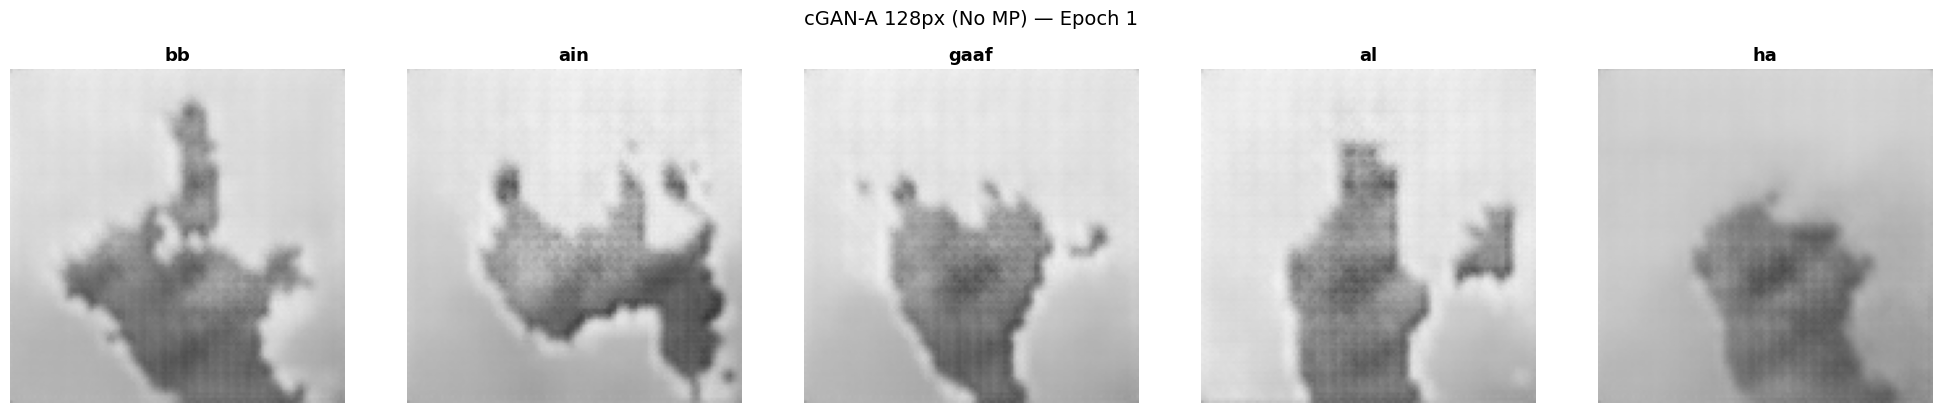

  ep  2 st   0 D=1.2834 Ga=0.8319 Gp=0.2131 lam=0.95 n_G=2
  ep  2 st 200 D=1.3206 Ga=0.8802 Gp=0.2622 lam=0.95 n_G=2
  ep  2 st 400 D=1.3193 Ga=0.8831 Gp=0.2661 lam=0.95 n_G=2
  ep  2 st 600 D=1.3207 Ga=0.8810 Gp=0.2684 lam=0.95 n_G=2
  ep  2 st 800 D=1.3197 Ga=0.8825 Gp=0.2683 lam=0.95 n_G=2
  ep  2 st1000 D=1.3205 Ga=0.8816 Gp=0.2684 lam=0.95 n_G=2
  ep  2 st1200 D=1.3185 Ga=0.8848 Gp=0.2680 lam=0.95 n_G=2
  ep  2 st1400 D=1.3187 Ga=0.8850 Gp=0.2679 lam=0.95 n_G=2
  ep  2 st1600 D=1.3188 Ga=0.8848 Gp=0.2682 lam=0.95 n_G=2

Ep2/50 [P1]: D=1.3190 Ga=0.8849 Gp=0.2682 Gt=1.1396 G/D=0.86x lam=0.95 Pixel%=22.4% n_G=2
  ep  3 st   0 D=1.3694 Ga=0.8508 Gp=0.2943 lam=1.40 n_G=2
  ep  3 st 200 D=1.2842 Ga=0.9360 Gp=0.2470 lam=1.40 n_G=2
  ep  3 st 400 D=1.2868 Ga=0.9296 Gp=0.2511 lam=1.40 n_G=2
  ep  3 st 600 D=1.2905 Ga=0.9237 Gp=0.2532 lam=1.40 n_G=2
  ep  3 st 800 D=1.2917 Ga=0.9209 Gp=0.2556 lam=1.40 n_G=2
  ep  3 st1000 D=1.2910 Ga=0.9207 Gp=0.2566 lam=1.40 n_G=2
  ep  3 st1200 D=1.2920 

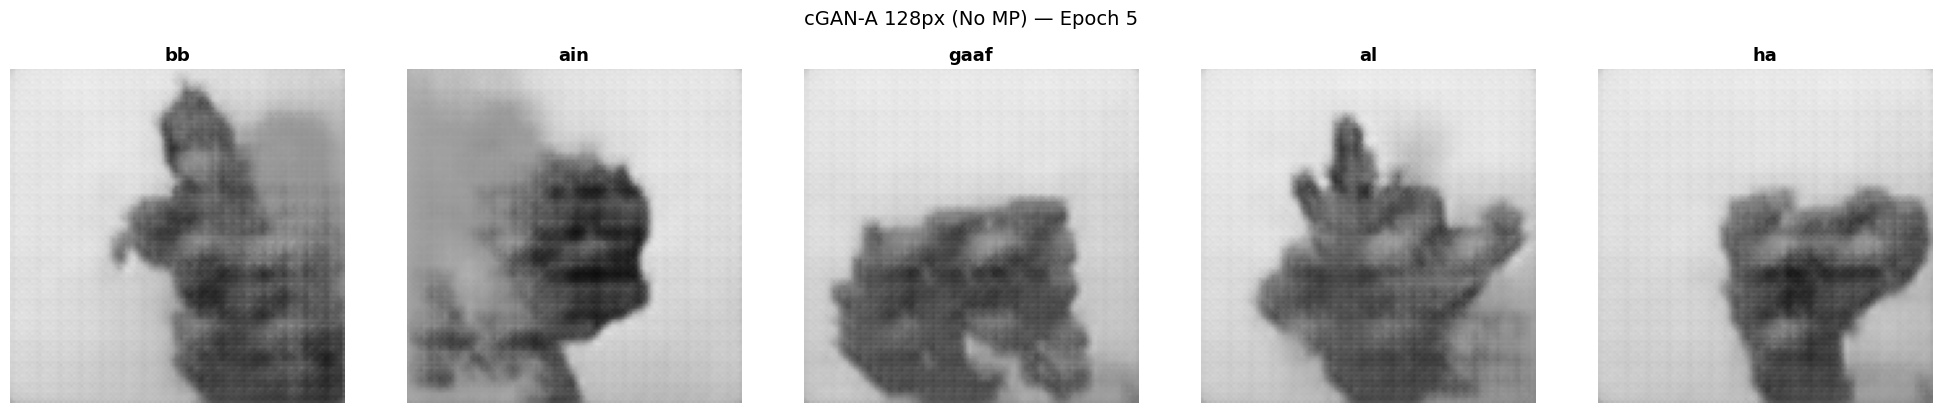

  ep  6 st   0 D=1.5294 Ga=0.9798 Gp=0.3319 lam=2.75 n_G=2
  ep  6 st 200 D=1.2739 Ga=0.9458 Gp=0.2574 lam=2.75 n_G=2
  ep  6 st 400 D=1.2783 Ga=0.9418 Gp=0.2591 lam=2.75 n_G=2
  ep  6 st 600 D=1.2782 Ga=0.9405 Gp=0.2589 lam=2.75 n_G=2
  ep  6 st 800 D=1.2778 Ga=0.9393 Gp=0.2597 lam=2.75 n_G=2
  ep  6 st1000 D=1.2774 Ga=0.9386 Gp=0.2598 lam=2.75 n_G=2
  ep  6 st1200 D=1.2775 Ga=0.9378 Gp=0.2601 lam=2.75 n_G=2
  ep  6 st1400 D=1.2778 Ga=0.9376 Gp=0.2600 lam=2.75 n_G=2
  ep  6 st1600 D=1.2779 Ga=0.9371 Gp=0.2598 lam=2.75 n_G=2

Ep6/50 [P1]: D=1.2781 Ga=0.9369 Gp=0.2599 Gt=1.6517 G/D=1.29x lam=2.75 Pixel%=43.3% n_G=2
  ep  7 st   0 D=1.3391 Ga=0.9098 Gp=0.2856 lam=3.20 n_G=2
  ep  7 st 200 D=1.2747 Ga=0.9356 Gp=0.2604 lam=3.20 n_G=2
  ep  7 st 400 D=1.2753 Ga=0.9374 Gp=0.2592 lam=3.20 n_G=2
  ep  7 st 600 D=1.2755 Ga=0.9385 Gp=0.2589 lam=3.20 n_G=2
  ep  7 st 800 D=1.2754 Ga=0.9388 Gp=0.2588 lam=3.20 n_G=2
  ep  7 st1000 D=1.2745 Ga=0.9400 Gp=0.2588 lam=3.20 n_G=2
  ep  7 st1200 D=1.2749 

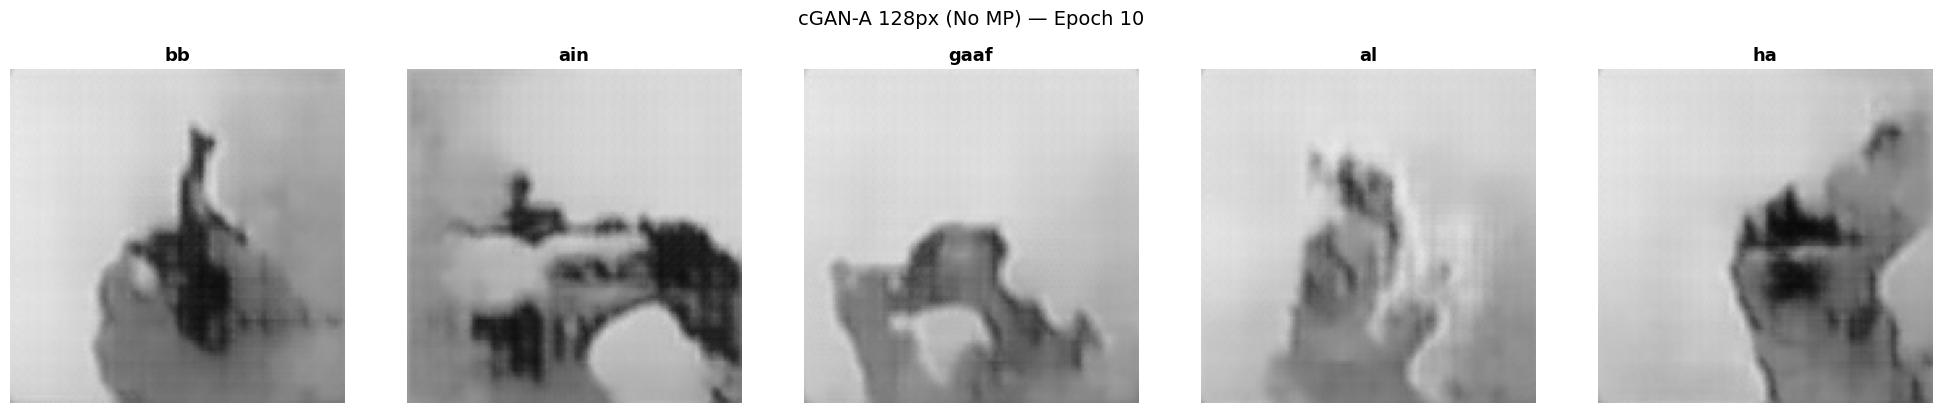

  ep 11 st   0 D=1.1682 Ga=0.9910 Gp=0.2489 lam=5.00 n_G=2
  ep 11 st 200 D=1.2712 Ga=0.9571 Gp=0.3520 lam=5.00 n_G=2
  ep 11 st 400 D=1.2667 Ga=0.9601 Gp=0.3559 lam=5.00 n_G=2
  ep 11 st 600 D=1.2650 Ga=0.9614 Gp=0.3569 lam=5.00 n_G=2
  ep 11 st 800 D=1.2638 Ga=0.9620 Gp=0.3569 lam=5.00 n_G=2
  ep 11 st1000 D=1.2640 Ga=0.9625 Gp=0.3573 lam=5.00 n_G=2
  ep 11 st1200 D=1.2637 Ga=0.9618 Gp=0.3582 lam=5.00 n_G=2
  ep 11 st1400 D=1.2632 Ga=0.9625 Gp=0.3587 lam=5.00 n_G=2
  ep 11 st1600 D=1.2630 Ga=0.9624 Gp=0.3596 lam=5.00 n_G=2

Ep11/50 [P2]: D=1.2628 Ga=0.9626 Gp=0.3597 Gt=2.7612 G/D=2.19x lam=5.00 Pixel%=65.1% n_G=2
  ep 12 st   0 D=1.3145 Ga=1.0482 Gp=0.3629 lam=5.00 n_G=3
  ep 12 st 200 D=1.2653 Ga=0.9568 Gp=0.3634 lam=5.00 n_G=3
  ep 12 st 400 D=1.2649 Ga=0.9584 Gp=0.3625 lam=5.00 n_G=3
  ep 12 st 600 D=1.2639 Ga=0.9591 Gp=0.3595 lam=5.00 n_G=3
  ep 12 st 800 D=1.2646 Ga=0.9582 Gp=0.3578 lam=5.00 n_G=3
  ep 12 st1000 D=1.2645 Ga=0.9587 Gp=0.3587 lam=5.00 n_G=3
  ep 12 st1200 D=1.2641

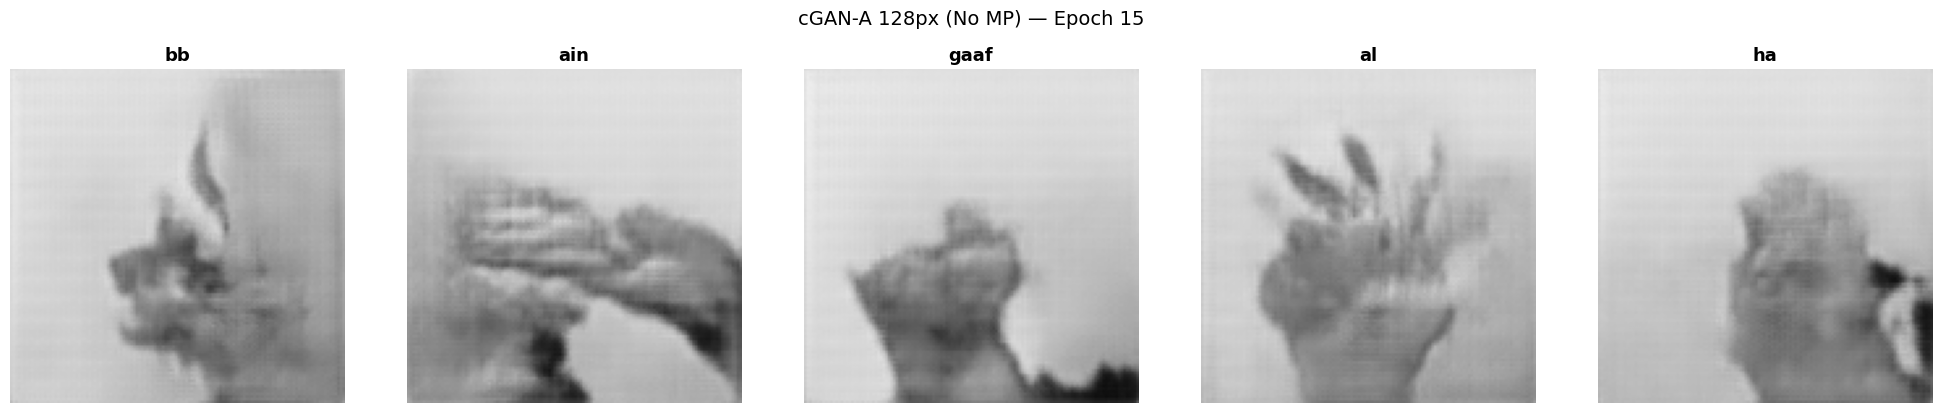

  ep 16 st   0 D=1.2838 Ga=0.9156 Gp=0.3122 lam=5.00 n_G=3
  ep 16 st 200 D=1.2638 Ga=0.9592 Gp=0.3567 lam=5.00 n_G=3
  ep 16 st 400 D=1.2675 Ga=0.9534 Gp=0.3574 lam=5.00 n_G=3
  ep 16 st 600 D=1.2676 Ga=0.9533 Gp=0.3593 lam=5.00 n_G=3
  ep 16 st 800 D=1.2680 Ga=0.9542 Gp=0.3587 lam=5.00 n_G=3
  ep 16 st1000 D=1.2670 Ga=0.9548 Gp=0.3583 lam=5.00 n_G=3
  ep 16 st1200 D=1.2680 Ga=0.9535 Gp=0.3595 lam=5.00 n_G=3
  ep 16 st1400 D=1.2676 Ga=0.9543 Gp=0.3594 lam=5.00 n_G=3
  ep 16 st1600 D=1.2681 Ga=0.9537 Gp=0.3596 lam=5.00 n_G=3

Ep16/50 [P2]: D=1.2683 Ga=0.9535 Gp=0.3604 Gt=2.7555 G/D=2.17x lam=5.00 Pixel%=65.4% n_G=3
  ep 17 st   0 D=1.2620 Ga=0.9264 Gp=0.3769 lam=5.00 n_G=3
  ep 17 st 200 D=1.2712 Ga=0.9497 Gp=0.3582 lam=5.00 n_G=3
  ep 17 st 400 D=1.2691 Ga=0.9550 Gp=0.3580 lam=5.00 n_G=3
  ep 17 st 600 D=1.2689 Ga=0.9552 Gp=0.3582 lam=5.00 n_G=3
  ep 17 st 800 D=1.2683 Ga=0.9557 Gp=0.3588 lam=5.00 n_G=3
  ep 17 st1000 D=1.2686 Ga=0.9542 Gp=0.3590 lam=5.00 n_G=3
  ep 17 st1200 D=1.2691

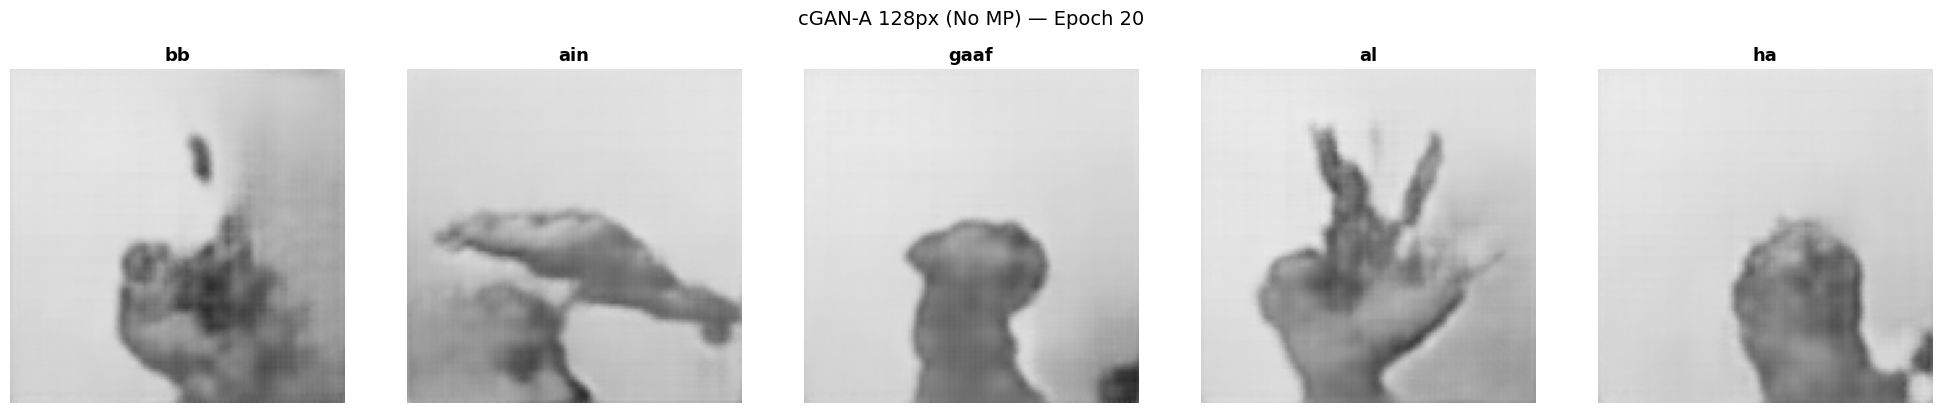

  [ep21] D LR decayed → 5e-05
  ep 21 st   0 D=1.2353 Ga=0.9514 Gp=0.4370 lam=5.00 n_G=3
  ep 21 st 200 D=1.2713 Ga=0.9384 Gp=0.3667 lam=5.00 n_G=3
  ep 21 st 400 D=1.2678 Ga=0.9436 Gp=0.3641 lam=5.00 n_G=3
  ep 21 st 600 D=1.2675 Ga=0.9432 Gp=0.3628 lam=5.00 n_G=3
  ep 21 st 800 D=1.2665 Ga=0.9440 Gp=0.3617 lam=5.00 n_G=3
  ep 21 st1000 D=1.2671 Ga=0.9443 Gp=0.3629 lam=5.00 n_G=3
  ep 21 st1200 D=1.2664 Ga=0.9449 Gp=0.3619 lam=5.00 n_G=3
  ep 21 st1400 D=1.2666 Ga=0.9448 Gp=0.3629 lam=5.00 n_G=3
  ep 21 st1600 D=1.2666 Ga=0.9453 Gp=0.3626 lam=5.00 n_G=3

Ep21/50 [P2]: D=1.2663 Ga=0.9452 Gp=0.3627 Gt=2.7589 G/D=2.18x lam=5.00 Pixel%=65.7% n_G=3
  ep 22 st   0 D=1.3030 Ga=0.9938 Gp=0.3212 lam=5.00 n_G=3
  ep 22 st 200 D=1.2620 Ga=0.9537 Gp=0.3632 lam=5.00 n_G=3
  ep 22 st 400 D=1.2659 Ga=0.9466 Gp=0.3652 lam=5.00 n_G=3
  ep 22 st 600 D=1.2671 Ga=0.9451 Gp=0.3643 lam=5.00 n_G=3
  ep 22 st 800 D=1.2659 Ga=0.9481 Gp=0.3615 lam=5.00 n_G=3
  ep 22 st1000 D=1.2649 Ga=0.9485 Gp=0.3612 lam=5.00

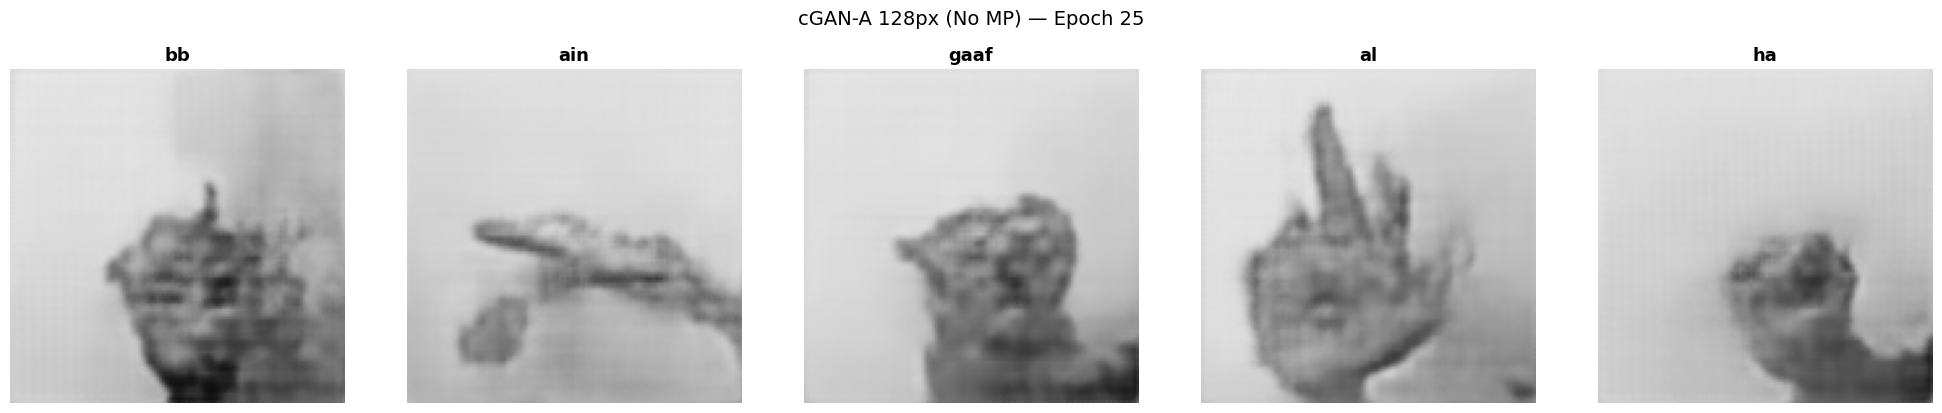

  ep 26 st   0 D=1.2504 Ga=0.9503 Gp=0.3626 lam=5.00 n_G=3
  ep 26 st 200 D=1.2689 Ga=0.9399 Gp=0.3535 lam=5.00 n_G=3
  ep 26 st 400 D=1.2692 Ga=0.9410 Gp=0.3570 lam=5.00 n_G=3
  ep 26 st 600 D=1.2679 Ga=0.9427 Gp=0.3592 lam=5.00 n_G=3
  ep 26 st 800 D=1.2670 Ga=0.9444 Gp=0.3587 lam=5.00 n_G=3
  ep 26 st1000 D=1.2664 Ga=0.9448 Gp=0.3593 lam=5.00 n_G=3
  ep 26 st1200 D=1.2663 Ga=0.9443 Gp=0.3607 lam=5.00 n_G=3
  ep 26 st1400 D=1.2667 Ga=0.9437 Gp=0.3611 lam=5.00 n_G=3
  ep 26 st1600 D=1.2667 Ga=0.9443 Gp=0.3612 lam=5.00 n_G=3

Ep26/50 [P2]: D=1.2666 Ga=0.9447 Gp=0.3615 Gt=2.7520 G/D=2.17x lam=5.00 Pixel%=65.7% n_G=3
  ep 27 st   0 D=1.2554 Ga=0.9535 Gp=0.4489 lam=5.00 n_G=3
  ep 27 st 200 D=1.2639 Ga=0.9489 Gp=0.3642 lam=5.00 n_G=3
  ep 27 st 400 D=1.2657 Ga=0.9472 Gp=0.3638 lam=5.00 n_G=3
  ep 27 st 600 D=1.2678 Ga=0.9436 Gp=0.3651 lam=5.00 n_G=3
  ep 27 st 800 D=1.2678 Ga=0.9430 Gp=0.3642 lam=5.00 n_G=3
  ep 27 st1000 D=1.2670 Ga=0.9442 Gp=0.3646 lam=5.00 n_G=3
  ep 27 st1200 D=1.2672

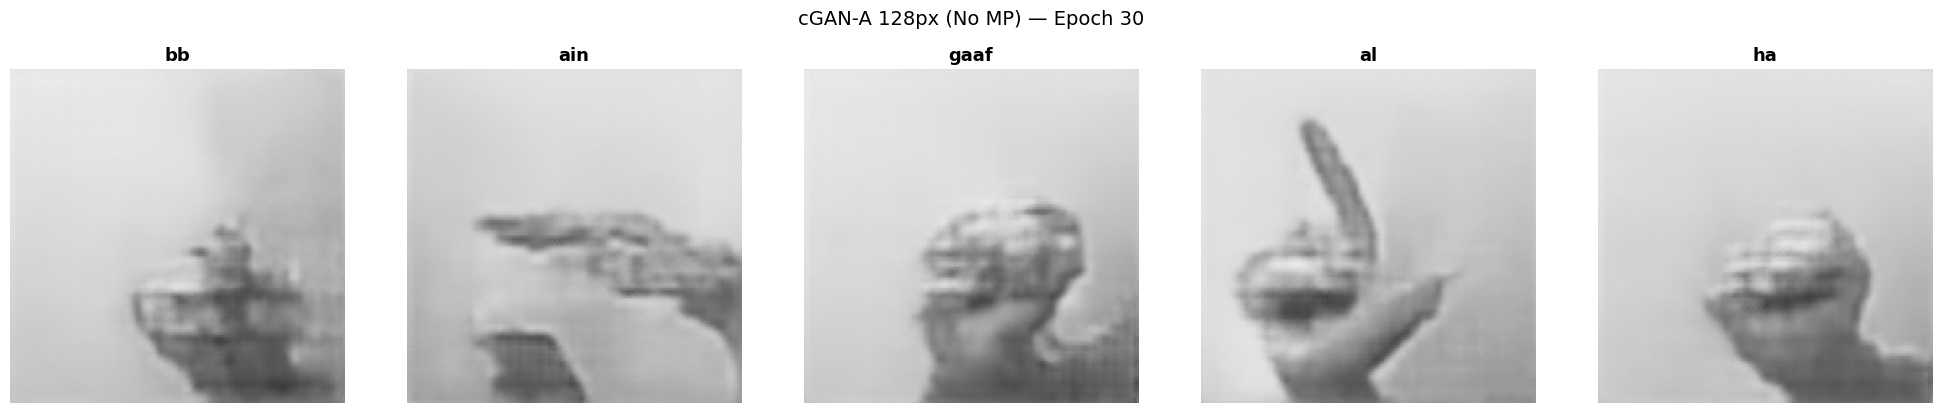

  ep 31 st   0 D=1.2760 Ga=0.8969 Gp=0.2727 lam=5.00 n_G=3
  ep 31 st 200 D=1.2634 Ga=0.9466 Gp=0.3716 lam=5.00 n_G=3
  ep 31 st 400 D=1.2645 Ga=0.9464 Gp=0.3676 lam=5.00 n_G=3
  ep 31 st 600 D=1.2674 Ga=0.9428 Gp=0.3689 lam=5.00 n_G=3
  ep 31 st 800 D=1.2683 Ga=0.9416 Gp=0.3682 lam=5.00 n_G=3
  ep 31 st1000 D=1.2682 Ga=0.9424 Gp=0.3663 lam=5.00 n_G=3
  ep 31 st1200 D=1.2682 Ga=0.9434 Gp=0.3666 lam=5.00 n_G=3
  ep 31 st1400 D=1.2680 Ga=0.9434 Gp=0.3658 lam=5.00 n_G=3
  ep 31 st1600 D=1.2679 Ga=0.9433 Gp=0.3654 lam=5.00 n_G=3

Ep31/50 [P2]: D=1.2676 Ga=0.9436 Gp=0.3653 Gt=2.7702 G/D=2.19x lam=5.00 Pixel%=65.9% n_G=3
  ep 32 st   0 D=1.2688 Ga=0.9781 Gp=0.4174 lam=5.00 n_G=3
  ep 32 st 200 D=1.2657 Ga=0.9472 Gp=0.3672 lam=5.00 n_G=3
  ep 32 st 400 D=1.2687 Ga=0.9438 Gp=0.3679 lam=5.00 n_G=3
  ep 32 st 600 D=1.2679 Ga=0.9443 Gp=0.3665 lam=5.00 n_G=3
  ep 32 st 800 D=1.2672 Ga=0.9448 Gp=0.3654 lam=5.00 n_G=3
  ep 32 st1000 D=1.2673 Ga=0.9451 Gp=0.3648 lam=5.00 n_G=3
  ep 32 st1200 D=1.2668

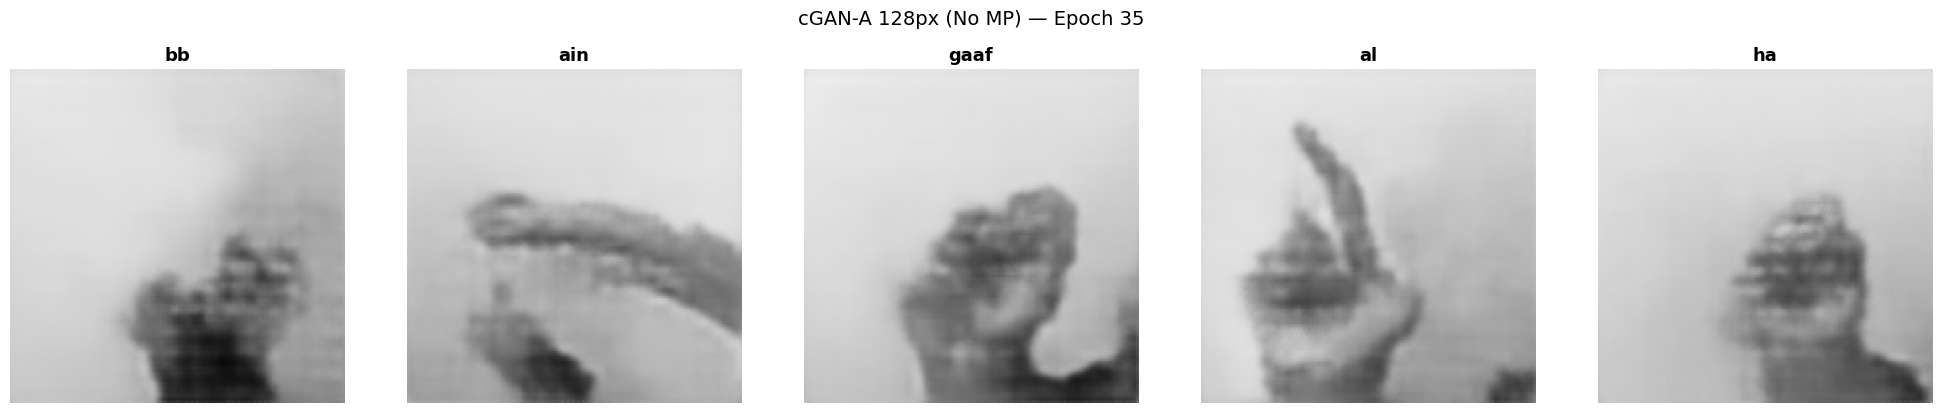

  [ep36] G LR decayed → 1e-04
  ep 36 st   0 D=1.2147 Ga=0.9180 Gp=0.2656 lam=5.00 n_G=3
  ep 36 st 200 D=1.2641 Ga=0.9405 Gp=0.3661 lam=5.00 n_G=3
  ep 36 st 400 D=1.2634 Ga=0.9432 Gp=0.3666 lam=5.00 n_G=3
  ep 36 st 600 D=1.2642 Ga=0.9428 Gp=0.3658 lam=5.00 n_G=3
  ep 36 st 800 D=1.2640 Ga=0.9434 Gp=0.3658 lam=5.00 n_G=3
  ep 36 st1000 D=1.2637 Ga=0.9443 Gp=0.3648 lam=5.00 n_G=3
  ep 36 st1200 D=1.2640 Ga=0.9433 Gp=0.3648 lam=5.00 n_G=3
  ep 36 st1400 D=1.2640 Ga=0.9438 Gp=0.3635 lam=5.00 n_G=3
  ep 36 st1600 D=1.2645 Ga=0.9434 Gp=0.3633 lam=5.00 n_G=3

Ep36/50 [P2]: D=1.2641 Ga=0.9444 Gp=0.3625 Gt=2.7569 G/D=2.18x lam=5.00 Pixel%=65.7% n_G=3
  ep 37 st   0 D=1.2070 Ga=0.9937 Gp=0.3844 lam=5.00 n_G=3
  ep 37 st 200 D=1.2639 Ga=0.9412 Gp=0.3656 lam=5.00 n_G=3
  ep 37 st 400 D=1.2659 Ga=0.9412 Gp=0.3665 lam=5.00 n_G=3
  ep 37 st 600 D=1.2656 Ga=0.9419 Gp=0.3671 lam=5.00 n_G=3
  ep 37 st 800 D=1.2652 Ga=0.9430 Gp=0.3652 lam=5.00 n_G=3
  ep 37 st1000 D=1.2651 Ga=0.9434 Gp=0.3656 lam=5.00

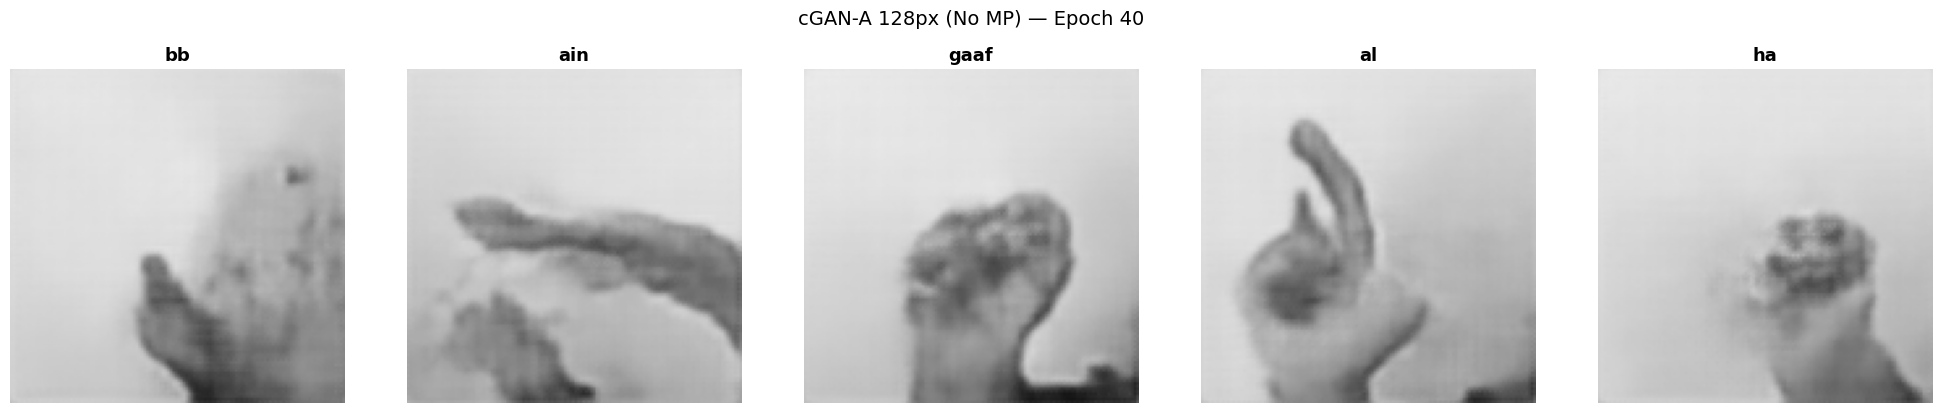

  ep 41 st   0 D=1.2748 Ga=0.9637 Gp=0.5188 lam=5.00 n_G=3
  ep 41 st 200 D=1.2600 Ga=0.9514 Gp=0.3660 lam=5.00 n_G=3
  ep 41 st 400 D=1.2628 Ga=0.9477 Gp=0.3649 lam=5.00 n_G=3
  ep 41 st 600 D=1.2627 Ga=0.9472 Gp=0.3661 lam=5.00 n_G=3
  ep 41 st 800 D=1.2636 Ga=0.9461 Gp=0.3654 lam=5.00 n_G=3
  ep 41 st1000 D=1.2632 Ga=0.9465 Gp=0.3646 lam=5.00 n_G=3
  ep 41 st1200 D=1.2629 Ga=0.9471 Gp=0.3636 lam=5.00 n_G=3
  ep 41 st1400 D=1.2630 Ga=0.9471 Gp=0.3635 lam=5.00 n_G=3
  ep 41 st1600 D=1.2633 Ga=0.9465 Gp=0.3640 lam=5.00 n_G=3

Ep41/50 [P2]: D=1.2633 Ga=0.9464 Gp=0.3636 Gt=2.7646 G/D=2.19x lam=5.00 Pixel%=65.8% n_G=3
  ep 42 st   0 D=1.2581 Ga=0.9211 Gp=0.3084 lam=5.00 n_G=3
  ep 42 st 200 D=1.2605 Ga=0.9471 Gp=0.3635 lam=5.00 n_G=3
  ep 42 st 400 D=1.2619 Ga=0.9477 Gp=0.3642 lam=5.00 n_G=3
  ep 42 st 600 D=1.2624 Ga=0.9478 Gp=0.3628 lam=5.00 n_G=3
  ep 42 st 800 D=1.2620 Ga=0.9480 Gp=0.3642 lam=5.00 n_G=3
  ep 42 st1000 D=1.2618 Ga=0.9485 Gp=0.3629 lam=5.00 n_G=3
  ep 42 st1200 D=1.2616

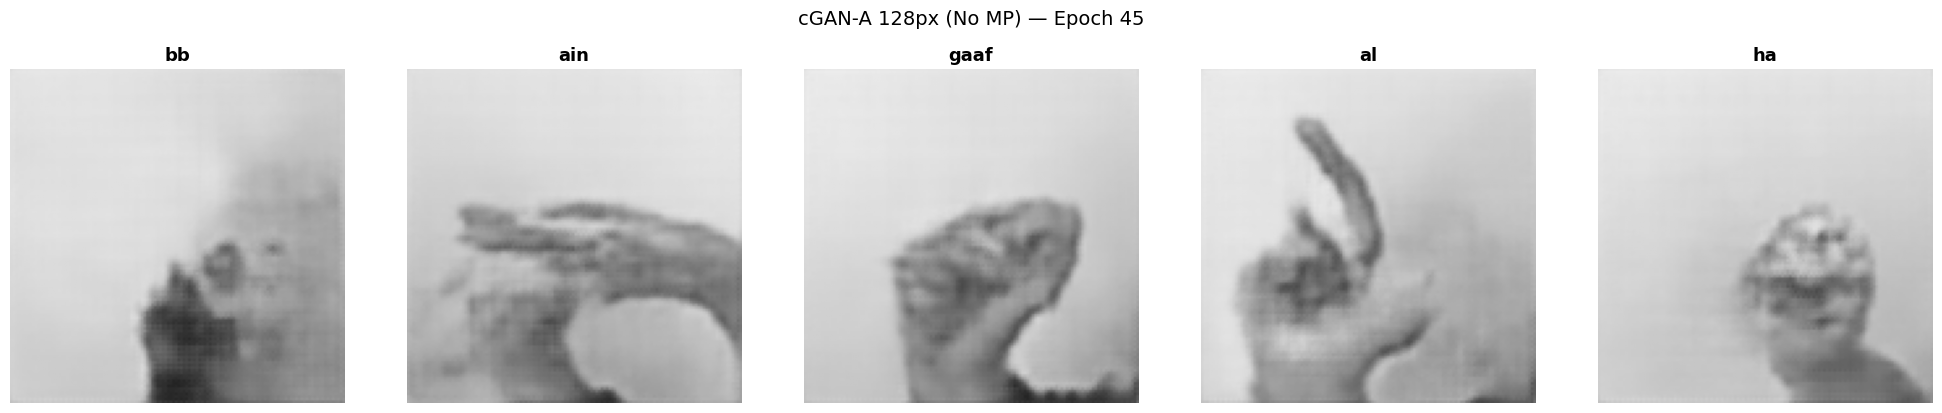

  ep 46 st   0 D=1.2264 Ga=0.9340 Gp=0.4918 lam=5.00 n_G=3
  ep 46 st 200 D=1.2612 Ga=0.9484 Gp=0.3628 lam=5.00 n_G=3
  ep 46 st 400 D=1.2625 Ga=0.9494 Gp=0.3621 lam=5.00 n_G=3
  ep 46 st 600 D=1.2613 Ga=0.9503 Gp=0.3612 lam=5.00 n_G=3
  ep 46 st 800 D=1.2626 Ga=0.9489 Gp=0.3619 lam=5.00 n_G=3
  ep 46 st1000 D=1.2628 Ga=0.9487 Gp=0.3635 lam=5.00 n_G=3
  ep 46 st1200 D=1.2621 Ga=0.9494 Gp=0.3623 lam=5.00 n_G=3
  ep 46 st1400 D=1.2624 Ga=0.9490 Gp=0.3627 lam=5.00 n_G=3
  ep 46 st1600 D=1.2621 Ga=0.9496 Gp=0.3632 lam=5.00 n_G=3

Ep46/50 [P2]: D=1.2620 Ga=0.9493 Gp=0.3637 Gt=2.7680 G/D=2.19x lam=5.00 Pixel%=65.7% n_G=3
  ep 47 st   0 D=1.3002 Ga=0.9024 Gp=0.3057 lam=5.00 n_G=3
  ep 47 st 200 D=1.2571 Ga=0.9562 Gp=0.3643 lam=5.00 n_G=3
  ep 47 st 400 D=1.2607 Ga=0.9514 Gp=0.3639 lam=5.00 n_G=3
  ep 47 st 600 D=1.2609 Ga=0.9512 Gp=0.3645 lam=5.00 n_G=3
  ep 47 st 800 D=1.2615 Ga=0.9506 Gp=0.3657 lam=5.00 n_G=3
  ep 47 st1000 D=1.2610 Ga=0.9524 Gp=0.3662 lam=5.00 n_G=3
  ep 47 st1200 D=1.2609

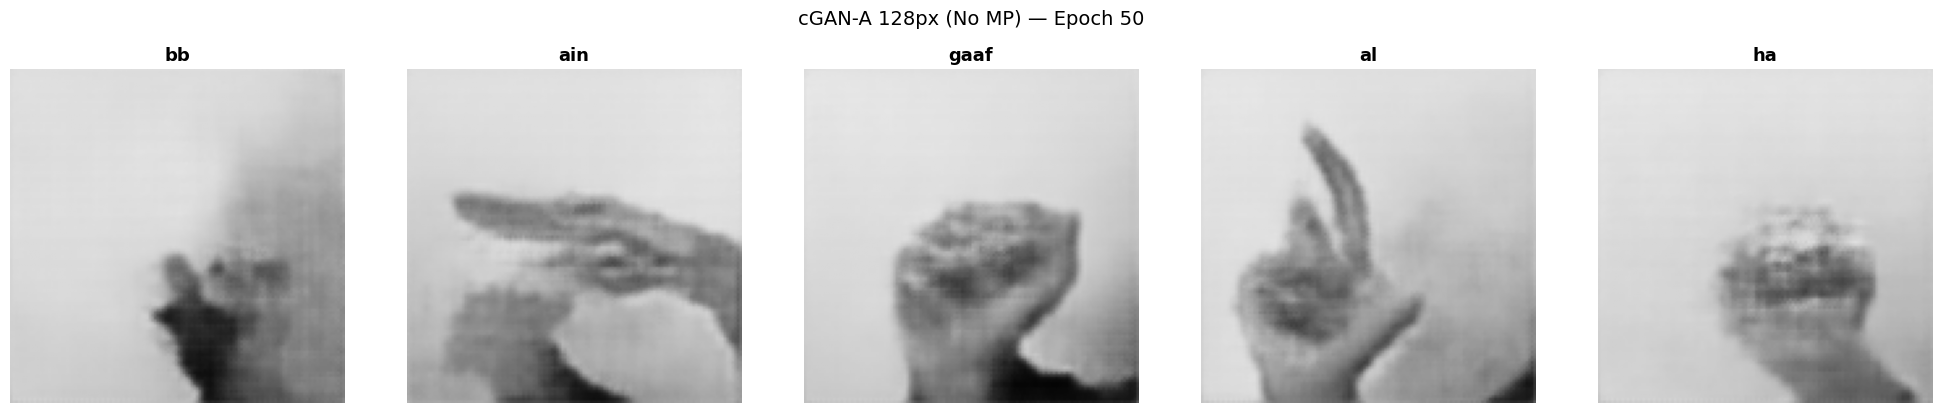


Training complete.


In [20]:
# ── Run training ───────────────────────────────────────────────────────────────
print("Starting Model A — cGAN 128×128 (No MediaPipe)")
print(f"LR_G={LR_G}  LR_D={LR_D}  (asymmetric)")
print(f"D decay ep{LR_DECAY_D}  G decay ep{LR_DECAY_G}")
print(f"lambda warm-up: {LAMBDA_START}→{LAMBDA_END} over ep1-{WARMUP_EP}")
print()

hist = train_A(
    generator=generator, discriminator=discriminator,
    images=images_array, labels=labels_int,
    class_img_proto_tf=class_img_proto_tf, class_real_indices=class_real_indices,
    z_dim=Z_DIM, num_classes=num_classes, epochs=EPOCHS, batch_size=BATCH_SIZE)


## Section 8 — Loss Curves

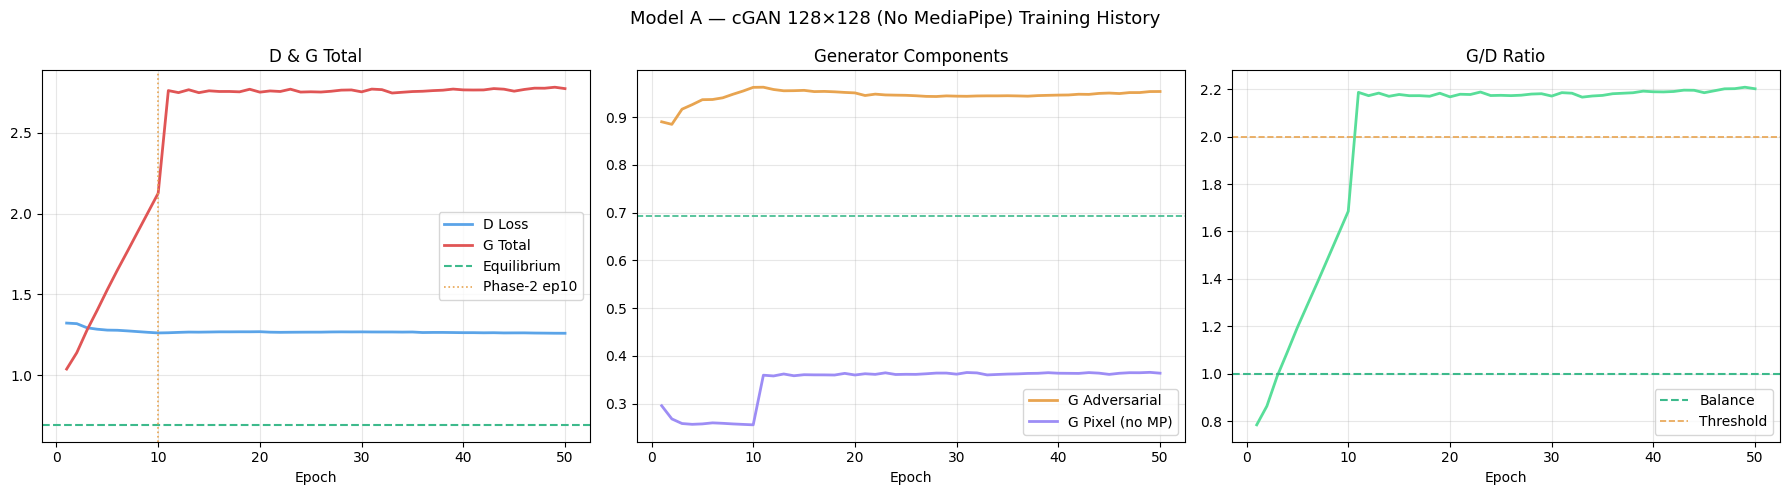

Saved: /content/drive/MyDrive/cgan_A_128/plots/A_loss_curves.png


In [21]:
# ── Loss curves ────────────────────────────────────────────────────────────────
def plot_losses(hist, save_dir=PLOTS_DIR):
    if not hist.get("d"):
        print("No history."); return
    ep  = list(range(1, len(hist["d"]) + 1))
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(ep, hist["d"],       '#5ba4e8', lw=2, label='D Loss')
    axes[0].plot(ep, hist["g_total"], '#e05555', lw=2, label='G Total')
    axes[0].axhline(0.693, color='#3dba8c', ls='--', lw=1.5, label='Equilibrium')
    axes[0].axvline(PHASE2_EP, color='#e8a450', ls=':', lw=1.2, label=f'Phase-2 ep{PHASE2_EP}')
    axes[0].set(title='D & G Total', xlabel='Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(ep, hist["g_adv"],   '#e8a450', lw=2, label='G Adversarial')
    axes[1].plot(ep, hist["g_pixel"], '#9d8df5', lw=2, label='G Pixel (no MP)')
    axes[1].axhline(0.693, color='#3dba8c', ls='--', lw=1.2)
    axes[1].set(title='Generator Components', xlabel='Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(ep, hist["gd_ratio"], '#58de99', lw=2)
    axes[2].axhline(1.0, color='#3dba8c', ls='--', lw=1.5, label='Balance')
    axes[2].axhline(G_D_RATIO_MAX, color='#e8a450', ls='--', lw=1.2, label=f'Threshold')
    axes[2].set(title='G/D Ratio', xlabel='Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle("Model A — cGAN 128×128 (No MediaPipe) Training History", fontsize=13)
    plt.tight_layout()
    p = os.path.join(save_dir, "A_loss_curves.png")
    plt.savefig(p, dpi=300, bbox_inches='tight'); plt.show(); plt.close()
    print(f"Saved: {p}")

plot_losses(hist)


## Section 9 — Evaluation Suite

In [22]:
try:
    from pytorch_fid import fid_score
    import torch
except ImportError:
    import subprocess; subprocess.run(["pip","install","pytorch-fid","--quiet"])
    from pytorch_fid import fid_score; import torch
FID_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"FID device: {FID_DEVICE}")


FID device: cuda


In [23]:
def save_balanced_real(imgs, lbls, out_dir, n_per_class=N_FID_PER_CLASS):
    os.makedirs(out_dir, exist_ok=True)
    cnt = 0
    for ci in range(num_classes):
        for i in np.where(lbls == ci)[0][:n_per_class]:
            img = (imgs[i,:,:,0]*127.5+127.5).clip(0,255).astype(np.uint8)
            Image.fromarray(np.stack([img,img,img],-1)).save(
                os.path.join(out_dir, f"r_{cnt:05d}.png")); cnt += 1
    print(f"Saved {cnt} balanced real images ({n_per_class}/class)")

def compute_fid(gen, num_cls, z_dim, real_dir, eval_dir,
                 n_runs=N_FID_SEEDS, n_per=N_FID_PER_CLASS):
    scores = []
    for seed in range(n_runs):
        gdir = os.path.join(eval_dir, f"fid_fake_s{seed:02d}")
        os.makedirs(gdir, exist_ok=True)
        tf.random.set_seed(seed); cnt = 0
        for ci in range(num_cls):
            loh   = tf.one_hot([ci]*n_per, depth=num_cls)
            noise = tf.random.normal([n_per, z_dim], seed=seed*100+ci)
            fakes = gen([noise, loh], training=False).numpy()
            for j in range(n_per):
                img = (fakes[j,:,:,0]*127.5+127.5).clip(0,255).astype(np.uint8)
                Image.fromarray(np.stack([img,img,img],-1)).save(
                    os.path.join(gdir, f"f_{cnt:05d}.png")); cnt += 1
        fv = fid_score.calculate_fid_given_paths(
            [real_dir, gdir], batch_size=32, device=FID_DEVICE, dims=2048)
        scores.append(fv); print(f"  Seed {seed}: FID={fv:.4f}")
    m, s = float(np.mean(scores)), float(np.std(scores))
    ci95  = 1.96*s/np.sqrt(n_runs)
    print(f"\nFID: {m:.4f} ± {s:.4f}  95%CI=[{m-ci95:.4f},{m+ci95:.4f}]")
    return m, s, scores

save_balanced_real(images_array, labels_int, REAL_FID_DIR)
fid_m, fid_s, fid_scores = compute_fid(generator, num_classes, Z_DIM, REAL_FID_DIR, EVAL_DIR)


Saved 1920 balanced real images (60/class)
Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:02<00:00, 35.1MB/s]
100%|██████████| 60/60 [00:18<00:00,  3.29it/s]


  Seed 0: FID=209.8965


100%|██████████| 60/60 [00:17<00:00,  3.39it/s]


  Seed 1: FID=212.7419


...

  Seed 2: FID=210.5147


100%|██████████| 60/60 [00:18<00:00,  3.32it/s]


  Seed 3: FID=208.8992


100%|██████████| 60/60 [00:17<00:00,  3.34it/s]


  Seed 4: FID=210.2103

FID: 210.4525 ± 1.2669  95%CI=[209.3420,211.5630]


In [24]:
def compute_ssim(gen, n_per=N_PKLE_PER_CLASS, seed=RANDOM_SEED):
    tf.random.set_seed(seed); np.random.seed(seed)
    all_s, per = [], {}
    for cname, ci in sorted(label_to_idx.items()):
        ridx  = np.where(labels_int==ci)[0][:n_per]
        if not len(ridx): continue
        loh   = tf.one_hot([ci]*len(ridx), depth=num_classes)
        noise = tf.random.normal([len(ridx), Z_DIM], seed=seed+ci)
        fakes = gen([noise, loh], training=False).numpy()
        cls_s = []
        for i in range(len(ridx)):
            r = (images_array[ridx[i],:,:,0]+1)/2
            f = (fakes[i,:,:,0]+1)/2
            cls_s.append(float(ssim_fn(r, f, data_range=1.0)))
            all_s.append(cls_s[-1])
        per[cname] = float(np.mean(cls_s))
    m = float(np.nanmean(all_s)); s = float(np.nanstd(all_s))
    print(f"SSIM: {m:.4f} ± {s:.4f}")
    return m, s, per

ssim_m, ssim_s, ssim_per = compute_ssim(generator)


SSIM: 0.5544 ± 0.1727


In [25]:
LPIPS_OK = False
try:
    import lpips as lpips_lib
    lpips_fn = lpips_lib.LPIPS(net='vgg'); LPIPS_OK = True
    print("LPIPS available (VGG)")
except ImportError:
    print("pip install lpips first")

def compute_lpips(gen, n_per=10, seed=RANDOM_SEED):
    if not LPIPS_OK: return float('nan'), float('nan'), {}
    import torch
    tf.random.set_seed(seed); np.random.seed(seed)
    all_l, per = [], {}
    for cname, ci in sorted(label_to_idx.items()):
        ridx  = np.where(labels_int==ci)[0][:n_per]
        if not len(ridx): continue
        loh   = tf.one_hot([ci]*len(ridx), depth=num_classes)
        noise = tf.random.normal([len(ridx), Z_DIM], seed=seed+ci)
        fakes = gen([noise, loh], training=False).numpy()
        cls_l = []
        for i in range(len(ridx)):
            def prep(arr):
                return torch.tensor(np.stack([arr[:,:,0]]*3, 0)[None], dtype=torch.float32)
            with torch.no_grad():
                d = lpips_fn(prep(images_array[ridx[i]]), prep(fakes[i])).item()
            cls_l.append(d); all_l.append(d)
        per[cname] = float(np.mean(cls_l))
    m = float(np.nanmean(all_l)); s = float(np.nanstd(all_l))
    print(f"LPIPS: {m:.4f} ± {s:.4f}")
    return m, s, per

lpips_m, lpips_s, lpips_per = compute_lpips(generator)


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 227MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
LPIPS available (VGG)
LPIPS: 0.4656 ± 0.0737


In [26]:
def compute_diversity(gen, n_per=10, seed=RANDOM_SEED):
    tf.random.set_seed(seed); np.random.seed(seed)
    all_d, per = [], {}
    for cname, ci in sorted(label_to_idx.items()):
        loh   = tf.one_hot([ci]*n_per, depth=num_classes)
        noise = tf.random.normal([n_per, Z_DIM], seed=seed+ci)
        fakes = gen([noise, loh], training=False).numpy().reshape(n_per, -1)
        dists = [float(np.mean(np.abs(fakes[i]-fakes[j])))
                  for i in range(n_per) for j in range(i+1, n_per)]
        d = float(np.mean(dists)) if dists else 0.0
        per[cname] = d; all_d.append(d)
    m = float(np.mean(all_d))
    print(f"Diversity: {m:.4f}  (mean intra-class L1; higher = more diverse)")
    return m, per

div_m, div_per = compute_diversity(generator)


Diversity: 0.1959  (mean intra-class L1; higher = more diverse)


## Section 10 — Save Results

In [27]:
def _nn(obj):
    if isinstance(obj, float) and obj != obj: return None
    if isinstance(obj, dict):  return {k: _nn(v) for k,v in obj.items()}
    if isinstance(obj, list):  return [_nn(i) for i in obj]
    return obj

results_A = {
    "model"    : "cGAN-A 128×128 (No MediaPipe)",
    "fid"      : {"mean": fid_m,   "std": fid_s,   "scores": fid_scores},
    "ssim"     : {"mean": ssim_m,  "std": ssim_s},
    "lpips"    : {"mean": lpips_m, "std": lpips_s},
    "diversity": {"mean": div_m},
    "training" : {"final_d":   hist["d"][-1]       if hist["d"]    else None,
                   "final_g_adv": hist["g_adv"][-1] if hist["g_adv"] else None,
                   "final_gd":  hist["gd_ratio"][-1] if hist["gd_ratio"] else None},
    "hyperparams": {"IMG_SIZE": IMG_SIZE, "Z_DIM": Z_DIM,
                     "LR_G": LR_G, "LR_D": LR_D, "EPOCHS": EPOCHS},
}

rp = os.path.join(HISTORY_DIR, "A_results.json")
with open(rp, "w") as f: json.dump(_nn(results_A), f, indent=2)
print(f"Results saved: {rp}")
print()
print(f"FID      : {fid_m:.4f} ± {fid_s:.4f}")
print(f"SSIM     : {ssim_m:.4f} ± {ssim_s:.4f}")
print(f"LPIPS    : {lpips_m:.4f} ± {lpips_s:.4f}")
print(f"Diversity: {div_m:.4f}")
print()
print("⚠  No PKLE metric — this model has no MediaPipe supervision.")
print("   Use Model B results for PKLE comparison.")


Results saved: /content/drive/MyDrive/cgan_A_128/history/A_results.json

FID      : 210.4525 ± 1.2669
SSIM     : 0.5544 ± 0.1727
LPIPS    : 0.4656 ± 0.0737
Diversity: 0.1959

⚠  No PKLE metric — this model has no MediaPipe supervision.
   Use Model B results for PKLE comparison.
